In [397]:
# importing libraries 

import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt

In [398]:
# Add CUDA device here later

In [399]:
# Reading libraries

words = open("names.txt", "r").read().splitlines()
len(words)

32033

In [400]:
# Mapping functions

chars = sorted(list(set(''.join(words))))

stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s, i in stoi.items()}

stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [401]:
# Defining the constants

block_size = 3
hidden_layers = 300
dimensions = 20
vocab_size = len(itos)

In [402]:
# Building the dataset

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0]*block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

# Traning validation and testing split

Xtr, Ytr = build_dataset(words[:n1])
Xva, Yva = build_dataset(words[n1: n2])
Xte, Yte = build_dataset(words[n2:])

print(Xtr.shape, Ytr.shape)
print(Xte.shape, Yte.shape)
print(Xte.shape, Yte.shape)

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22866, 3]) torch.Size([22866])
torch.Size([22866, 3]) torch.Size([22866])


In [403]:
# Multi Level Perceptron Parameters

g = torch.Generator().manual_seed(34)
C = torch.randn((vocab_size, dimensions),generator=g, requires_grad=True)
w1 = (torch.randn((dimensions*block_size, hidden_layers), generator=g) * 0.1).requires_grad_()
b1 = (torch.randn((hidden_layers), generator=g) * 0.01).requires_grad_()
w2 = (torch.randn((hidden_layers, vocab_size), generator=g) * 0.01).requires_grad_()
# b2 = (torch.randn(vocab_size, generator=g, requires_grad=True) * 0)
b2 = torch.zeros(vocab_size, requires_grad=True)

bngain = torch.ones((1,hidden_layers), requires_grad=True)
bnbias = torch.zeros((1,hidden_layers), requires_grad=True)

parameters = [C, w1, b1, w2, b2, bngain, bnbias]

print(sum(p.nelement() for p in parameters))

27567


In [ ]:
# Training loop with optimised steps

epochs = 100000
batch_size = 32
lossi = []

for i in range(epochs):
    # Minbatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    # Forward pass
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ w1 + b1

    # Batchnorm
    bnmeani = hpreact - hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = (bngain * bnmeani) / bnstdi + bnbias

    with torch.no_grad():
        bnmean_running = (0.999 * bnmean_running) + (bnmeani * 0.001)
        bnstd_running = (0.999 * bnstd_running) + (bnstdi * 0.001)

    h = torch.tanh(hpreact)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits, Yb)

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update learning rate
    lr = 0.01 if i < 10000 else 0.01
    for p in parameters  :
        p.data += -lr * p.grad

    # Track stats
    if i % 1000 == 0:
        print(loss, i)
    lossi.append(loss.log10().item())

tensor(3.2994, grad_fn=<NllLossBackward0>) 0
tensor(2.8969, grad_fn=<NllLossBackward0>) 1000
tensor(2.7261, grad_fn=<NllLossBackward0>) 2000
tensor(2.4472, grad_fn=<NllLossBackward0>) 3000
tensor(2.2399, grad_fn=<NllLossBackward0>) 4000
tensor(2.5374, grad_fn=<NllLossBackward0>) 5000
tensor(2.4266, grad_fn=<NllLossBackward0>) 6000
tensor(2.2040, grad_fn=<NllLossBackward0>) 7000
tensor(2.4267, grad_fn=<NllLossBackward0>) 8000
tensor(2.3532, grad_fn=<NllLossBackward0>) 9000
tensor(2.6166, grad_fn=<NllLossBackward0>) 10000
tensor(2.3603, grad_fn=<NllLossBackward0>) 11000
tensor(2.2127, grad_fn=<NllLossBackward0>) 12000
tensor(2.1655, grad_fn=<NllLossBackward0>) 13000
tensor(2.0684, grad_fn=<NllLossBackward0>) 14000
tensor(2.4885, grad_fn=<NllLossBackward0>) 15000
tensor(2.3281, grad_fn=<NllLossBackward0>) 16000
tensor(1.9725, grad_fn=<NllLossBackward0>) 17000
tensor(2.2997, grad_fn=<NllLossBackward0>) 18000
tensor(1.8650, grad_fn=<NllLossBackward0>) 19000
tensor(2.2730, grad_fn=<NllLossBa

In [405]:
# Calibrate batch norm at the end of traning

with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ w1 + b1
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)   

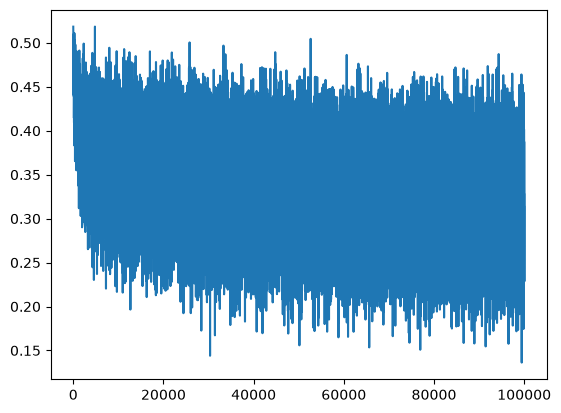

In [406]:
plt.plot(lossi)

In [407]:
hpreact.mean(0,keepdim=True).mean()

tensor(0.0148)

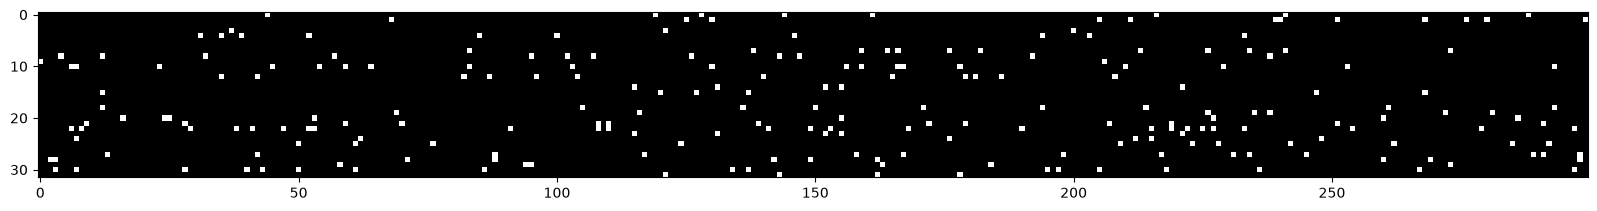

In [408]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99, cmap='grey', interpolation='nearest')

(array([448., 354., 278., 259., 252., 278., 219., 189., 225., 233., 179.,
        162., 157., 148., 163., 152., 140., 125., 141., 106., 118., 120.,
        123., 124., 119., 111., 110., 118., 115., 122., 136., 123., 115.,
        174., 136., 132., 136., 186., 189., 201., 193., 212., 228., 233.,
        218., 239., 293., 276., 341., 451.]),
 array([-9.99735355e-01, -9.59745106e-01, -9.19754856e-01, -8.79764606e-01,
        -8.39774356e-01, -7.99784106e-01, -7.59793856e-01, -7.19803606e-01,
        -6.79813356e-01, -6.39823107e-01, -5.99832857e-01, -5.59842607e-01,
        -5.19852357e-01, -4.79862107e-01, -4.39871857e-01, -3.99881607e-01,
        -3.59891357e-01, -3.19901108e-01, -2.79910858e-01, -2.39920608e-01,
        -1.99930358e-01, -1.59940108e-01, -1.19949858e-01, -7.99596083e-02,
        -3.99693584e-02,  2.08914280e-05,  4.00111413e-02,  8.00013912e-02,
         1.19991641e-01,  1.59981891e-01,  1.99972141e-01,  2.39962391e-01,
         2.79952641e-01,  3.19942890e-01,  3.59933

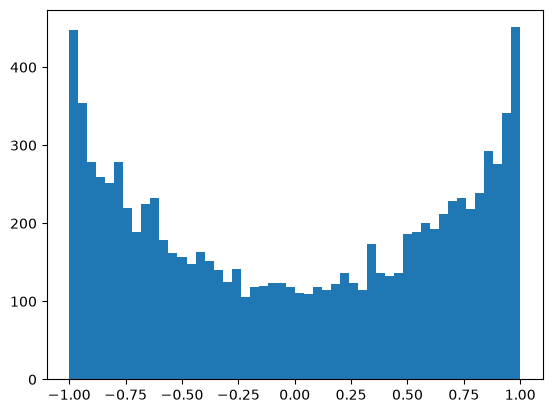

In [409]:
plt.hist(h.view(-1).tolist(),50)

In [410]:
# Evaluation
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train' : (Xtr, Ytr),
        'test' : (Xte, Yte), 
        'val' : (Xva, Yva)
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ w1 +b1
    # hpreact = (bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True)) + bnbias
    hpreact = (bngain * (hpreact - bnmean)) / bnstd + bnbias

    h = torch.tanh(hpreact)
    logits = h @ w2 + b2
    
    loss = F.cross_entropy(logits, y)
    print(split, loss)

split_loss('train')
split_loss('val')
split_loss('test')

train tensor(2.0912)
val tensor(2.1279)
test tensor(2.1244)


In [415]:
# Sampling from the model
max_len = 20
for _ in range(10):
    out = []
    context = [0]*block_size

    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(-1, block_size*dimensions) @ w1 + b1)
        o = h @ w2 + b2
        probs = F.softmax(o, dim=1)

        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0 or len(out) >= max_len:
            break

    print(''.join(itos[i] for i in out))

udemeslly.
leighnvir.
xuclakwim.
mahnznioubagt.
fimovylgimulaniysema
zhkyi.
hvibogwdinabmincyynt
vhaakikshuqzylemgele
shnq.
fydvann.
